In [1]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import csv

from scipy.stats import spearmanr
from scipy.spatial.distance import jensenshannon

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from plm_compare_progen2 import *
from plm_compare_esm import *
from protein_data import *

In [3]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

In [4]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/esm2_ProGym_matrices.pickle',
           'rb') as f:
    esm_dict = pickle.load(f)

In [5]:
keys = list(pg_dict.keys())

In [6]:
pg_sp_list=[]
esm_sp_list=[]
for key in keys:
    if 'spearman_DMS' in pg_dict[key].keys():
        pg_sp_val = pg_dict[key]['spearman_DMS']
        esm_sp_val = esm_dict[key]['spearman_DMS']

        pg_sp_list.append(pg_sp_val[0])
        esm_sp_list.append(esm_sp_val[0])

In [7]:
pg_sp_list[0]

np.float64(0.3791506937886044)

In [8]:
med_label_list=[]

for key in keys:
    if 'spearman_DMS' in pg_dict[key].keys():
        seq = pg_dict[key]['sequence']
        if len(seq) > 100 and len(seq) < 400:
            pg_sp_val = pg_dict[key]['spearman_DMS']
            esm_sp_val = esm_dict[key]['spearman_DMS']

            med_label_list.append((key, pg_sp_val[0], esm_sp_val[0]))

med_labels = [d[0] for d in med_label_list]
med_x = [d[1] for d in med_label_list]
med_y = [d[2] for d in med_label_list]



In [9]:
len(med_label_list)

54

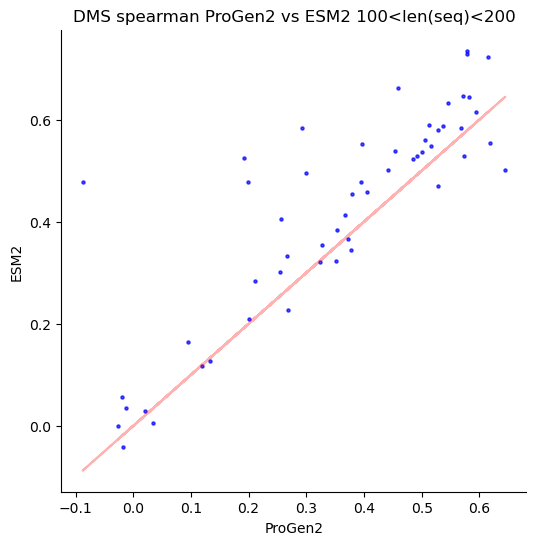

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(med_x, med_y, color='blue', alpha=0.7, s=5)
plt.plot(med_x, med_x, color='red', alpha=0.3)
plt.xlabel("ProGen2")
plt.ylabel("ESM2")
plt.title(f"DMS spearman ProGen2 vs ESM2 100<len(seq)<200")
plt.grid(False)
ax = plt.gca()
# ax.text(
#     0.01, 0.99,                
#     f"Spearman = {round(sp_val,5)}",
#     transform=plt.gca().transAxes,
#     fontsize=12,
#     verticalalignment='top',
#     horizontalalignment='left',
# )
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

In [15]:
print(sum(med_x)/len(med_x))
print(sum(med_y)/len(med_y))

0.354638125036011
0.4217326105517061


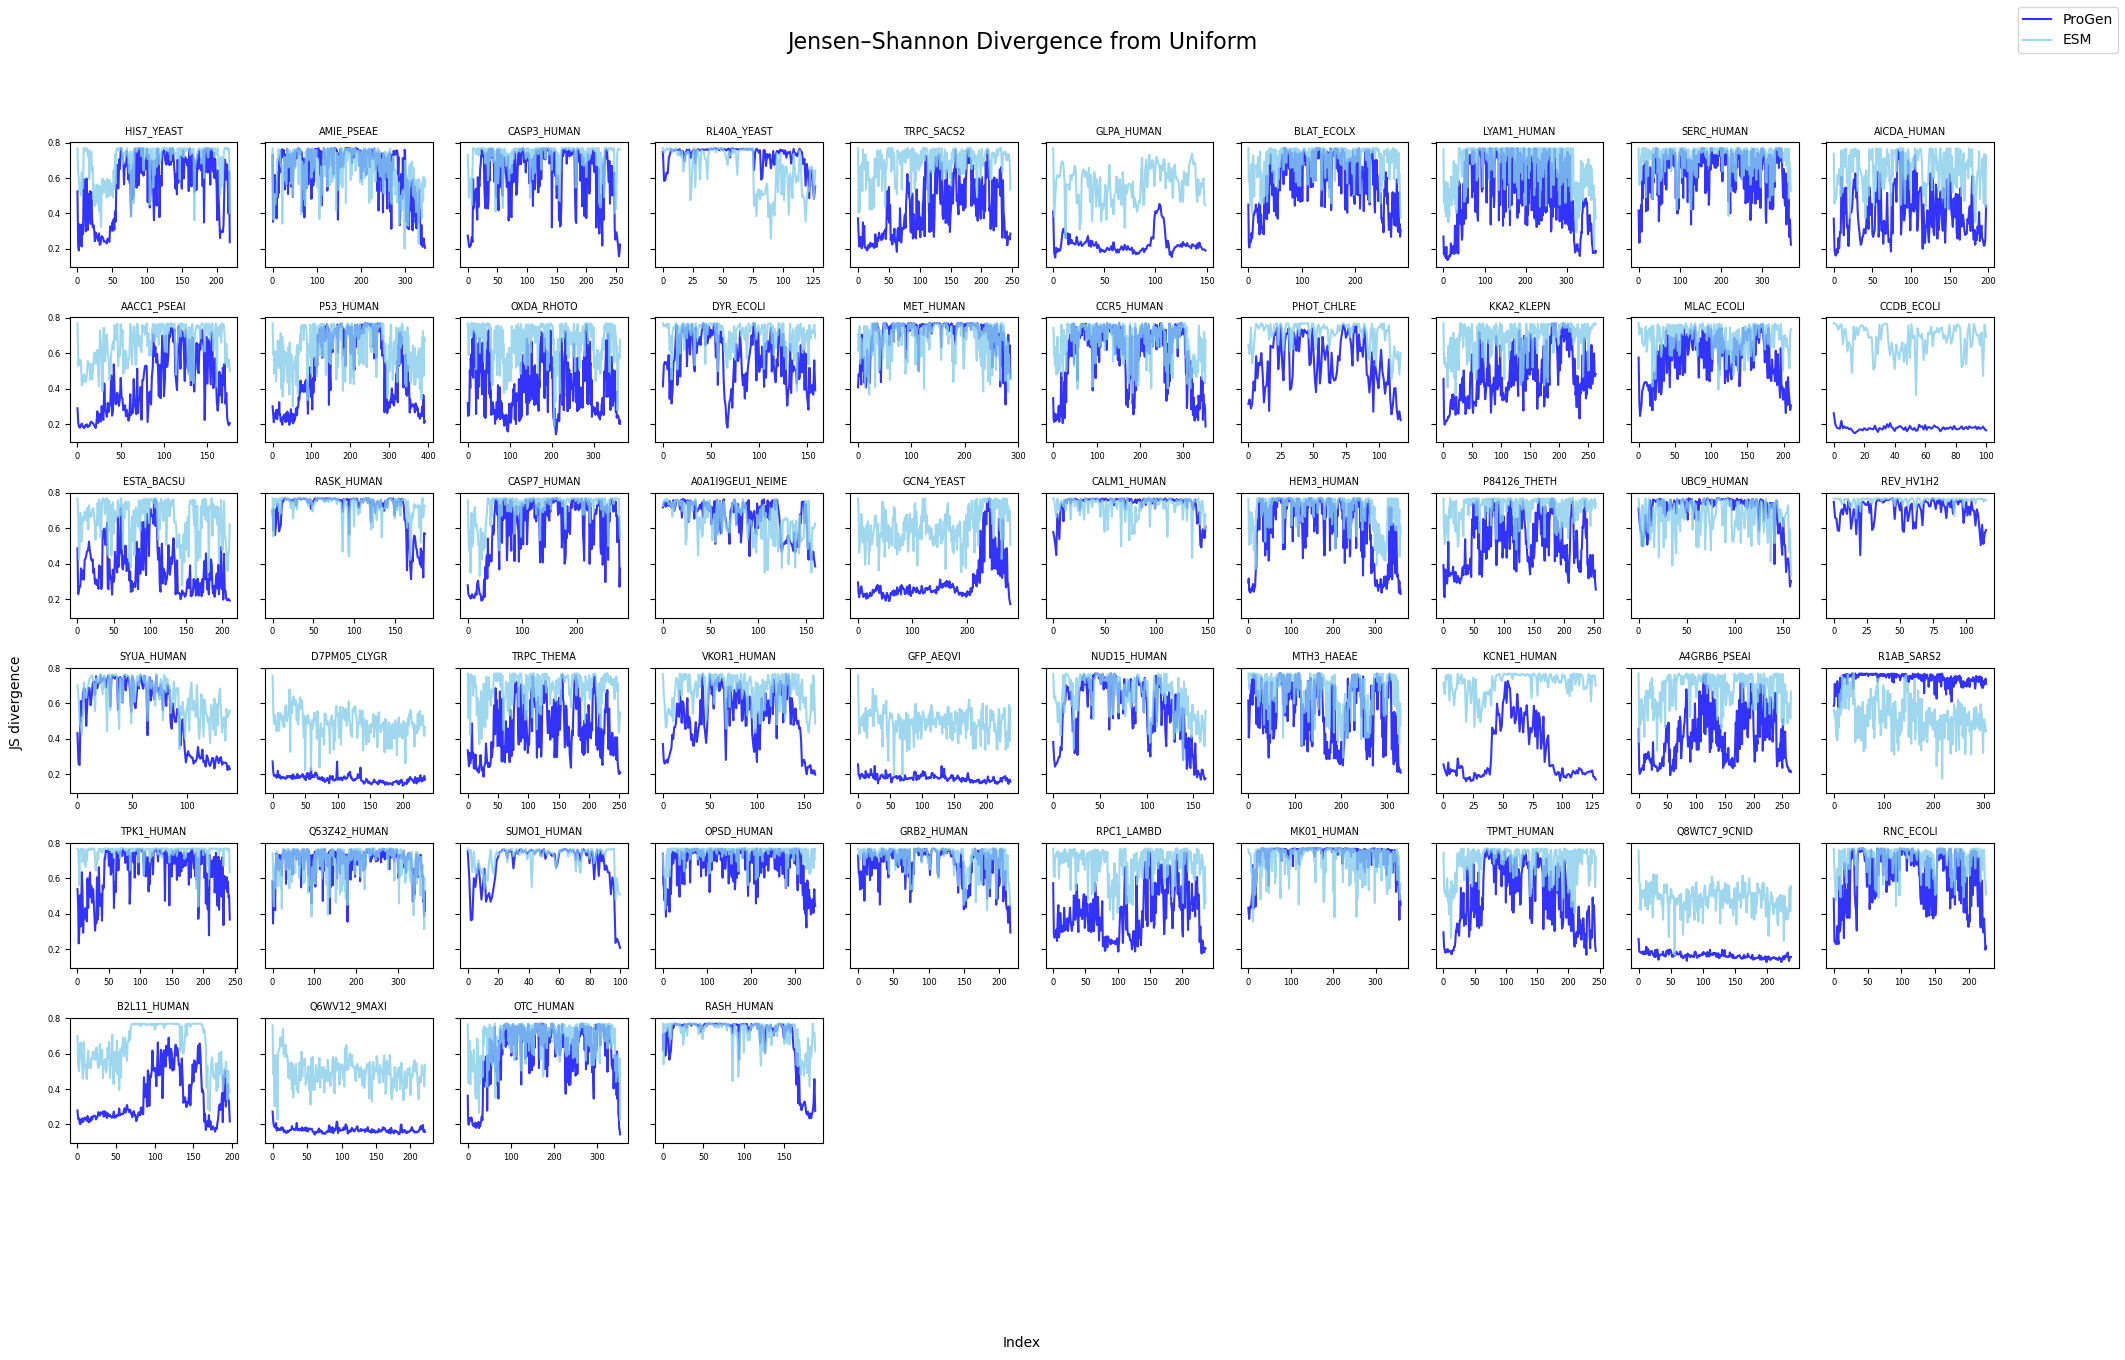

In [17]:
unif_dist = np.ones(20) / 20
n_plots = len(med_label_list)  # should be 69

n_cols = 10
n_rows = 7

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.2 * n_cols, 2.0 * n_rows),
    sharey=True
)

axes = axes.flatten()

for idx in range(n_plots):
    ax = axes[idx]
    key = med_label_list[idx][0]

    log_probs_pg = pg_dict[key]['log_probs']
    log_probs_esm = esm_dict[key]['log_probs']

    js_pg, js_esm = [], []

    for j in range(len(log_probs_pg)):
        p_pg = np.exp(log_probs_pg[j])
        p_pg /= p_pg.sum()
        js_pg.append(jensenshannon(p_pg, unif_dist))

        p_esm = np.exp(log_probs_esm[j])
        p_esm /= p_esm.sum()
        js_esm.append(jensenshannon(p_esm, unif_dist))

    ax.plot(js_pg, color='blue', alpha=0.8)
    ax.plot(js_esm, color='skyblue', alpha=0.8)

    ax.set_title(key, fontsize=7)
    ax.tick_params(axis='both', labelsize=6)
    ax.grid(False)

# Delete unused axes (70th panel)
for i in range(n_plots, n_rows * n_cols):
    fig.delaxes(axes[i])

# Global labels + legend
fig.suptitle("Jensen–Shannon Divergence from Uniform", fontsize=16)

fig.text(0.5, 0.04, "Index", ha="center")
fig.text(0.04, 0.5, "JS divergence", va="center", rotation="vertical")

fig.legend(
    ["ProGen", "ESM"],
    loc="upper right",
    fontsize=10
)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()


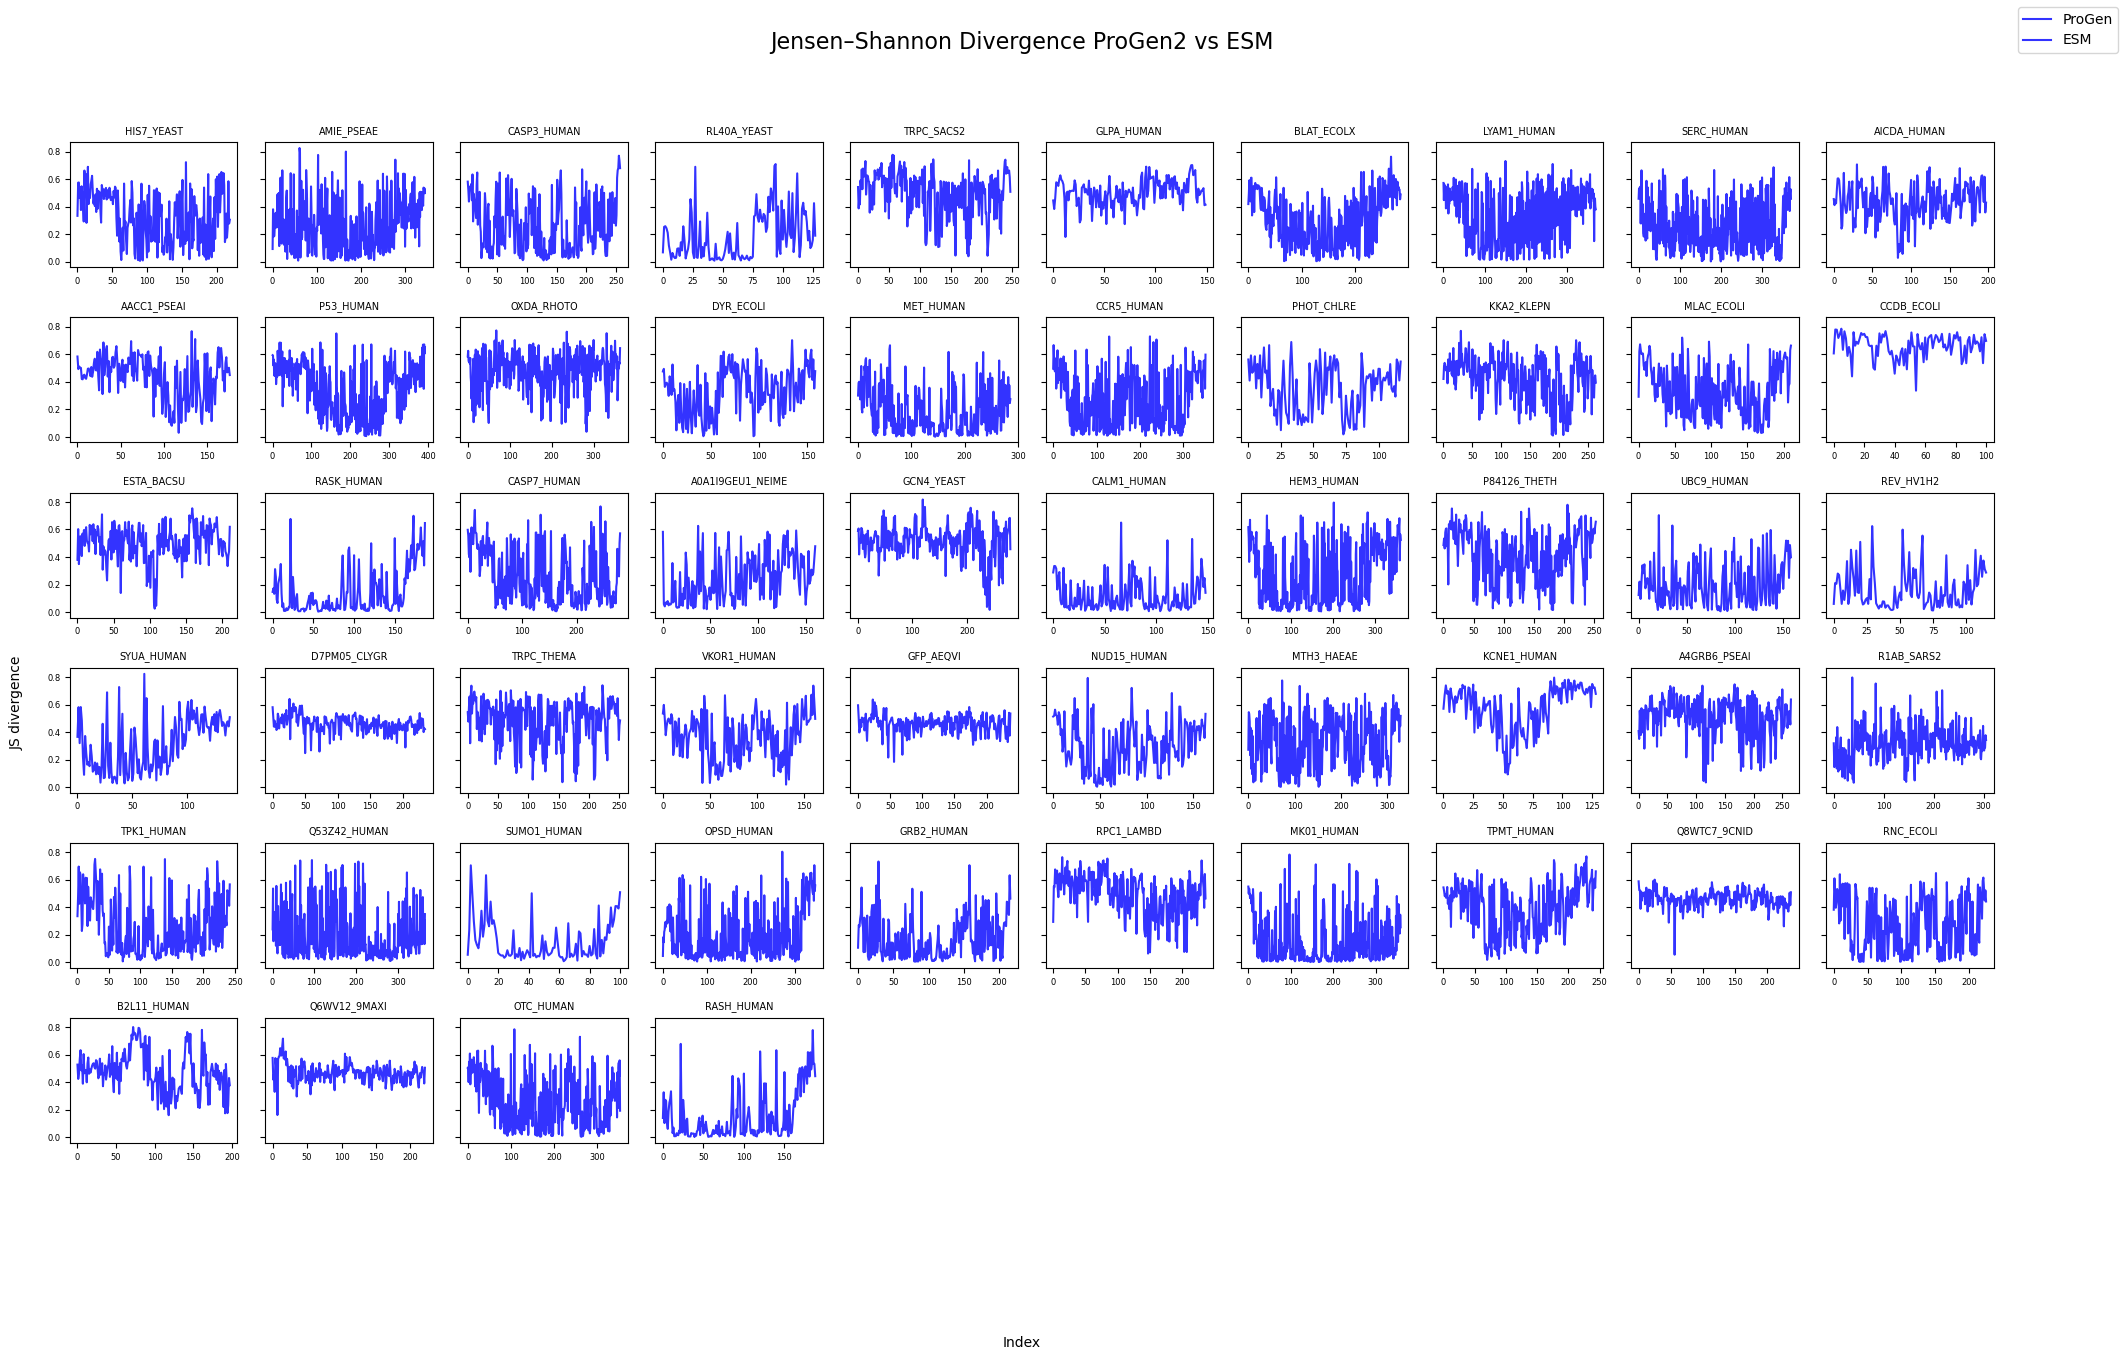

In [19]:
# unif_dist = np.ones(20) / 20
n_plots = len(med_label_list)  # should be 69

n_cols = 10
n_rows = 7

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.2 * n_cols, 2.0 * n_rows),
    sharey=True
)

axes = axes.flatten()

for idx in range(n_plots):
    ax = axes[idx]
    key = med_label_list[idx][0]

    log_probs_pg = pg_dict[key]['log_probs']
    log_probs_esm = esm_dict[key]['log_probs']

    js_pg_esm = []

    for j in range(len(log_probs_pg)):
        p_pg = np.exp(log_probs_pg[j])
        p_pg /= p_pg.sum()
        
        p_esm = np.exp(log_probs_esm[j])
        p_esm /= p_esm.sum()

        js_pg_esm.append(jensenshannon(p_pg, p_esm))

    ax.plot(js_pg_esm, color='blue', alpha=0.8)
    # ax.plot(js_esm, color='skyblue', alpha=0.8)

    ax.set_title(key, fontsize=7)
    ax.tick_params(axis='both', labelsize=6)
    ax.grid(False)

# Delete unused axes (70th panel)
for i in range(n_plots, n_rows * n_cols):
    fig.delaxes(axes[i])

# Global labels + legend
fig.suptitle("Jensen–Shannon Divergence ProGen2 vs ESM", fontsize=16)

fig.text(0.5, 0.04, "Index", ha="center")
fig.text(0.04, 0.5, "JS divergence", va="center", rotation="vertical")

fig.legend(
    ["ProGen", "ESM"],
    loc="upper right",
    fontsize=10
)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()


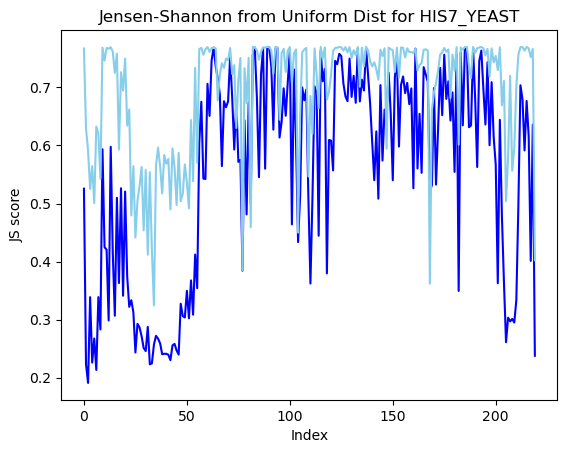

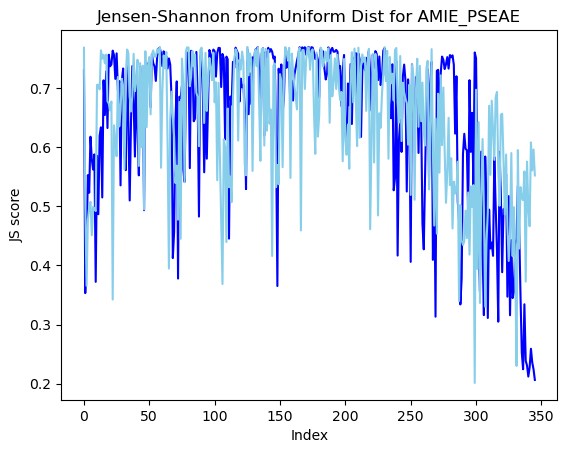

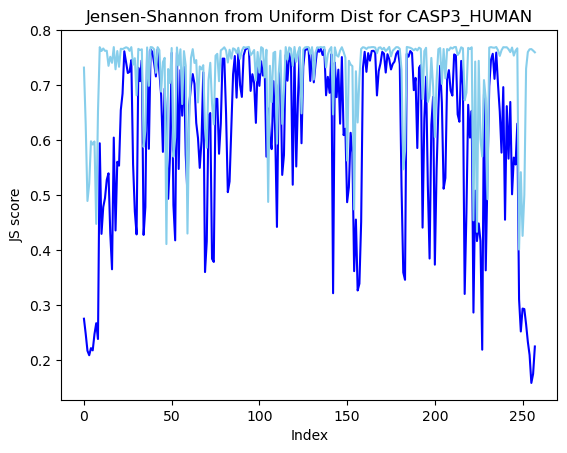

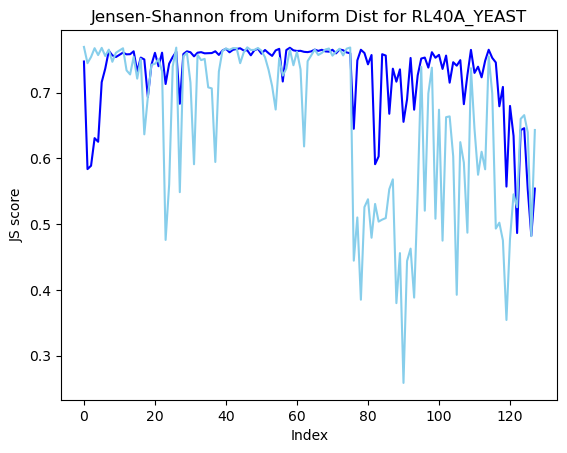

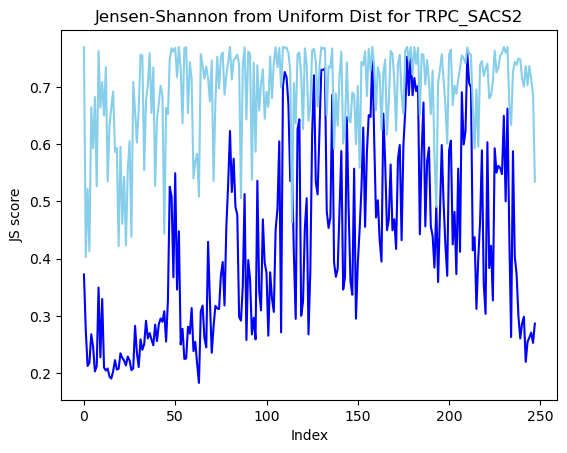

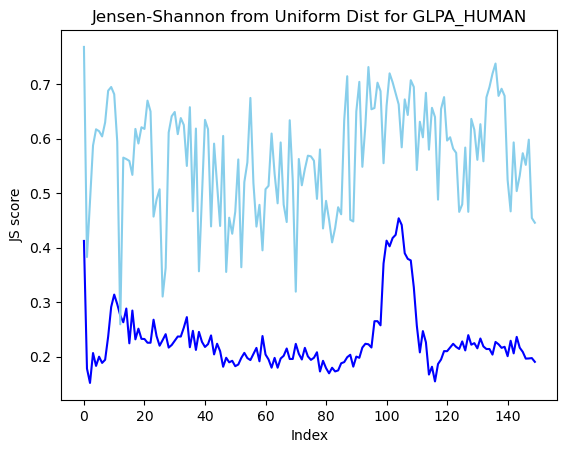

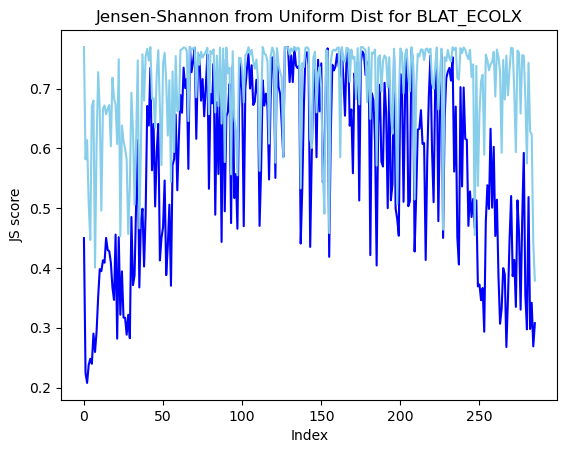

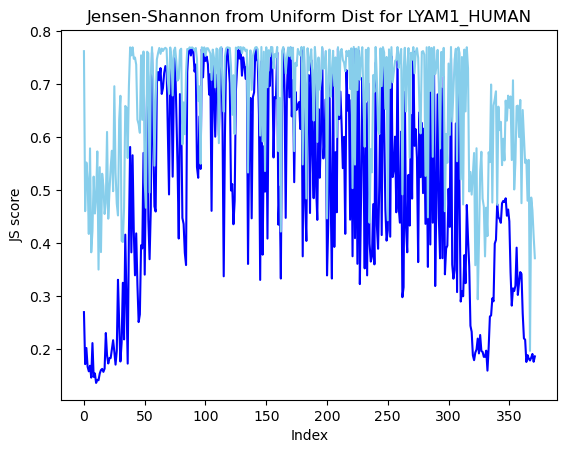

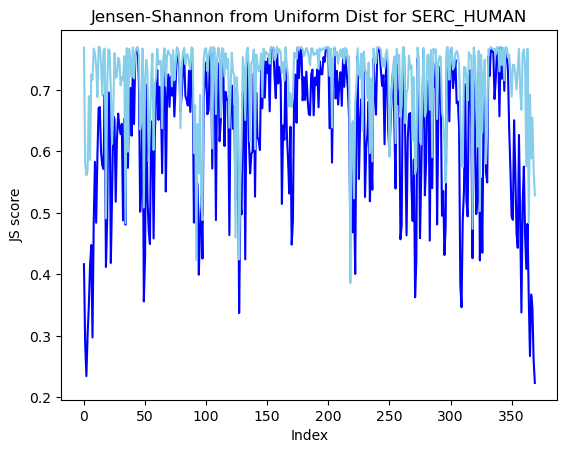

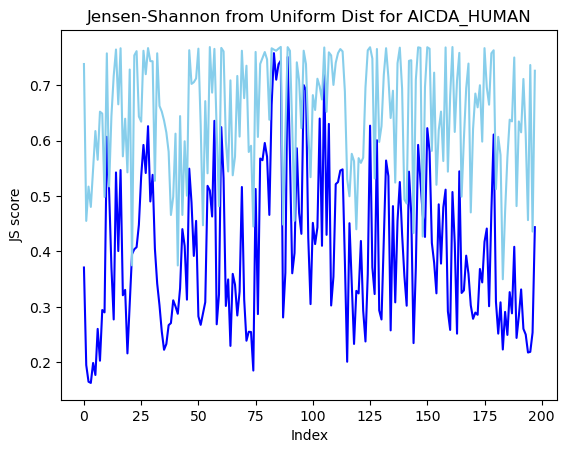

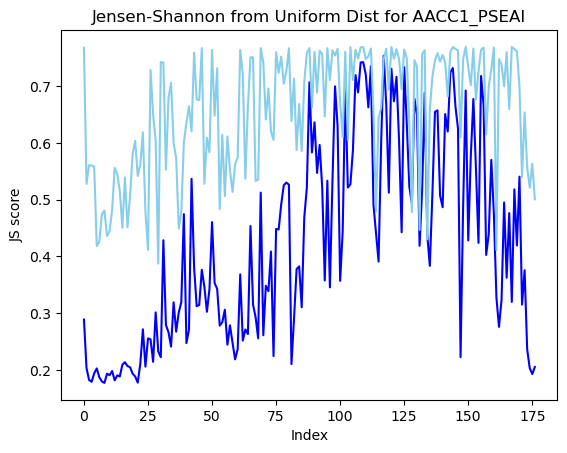

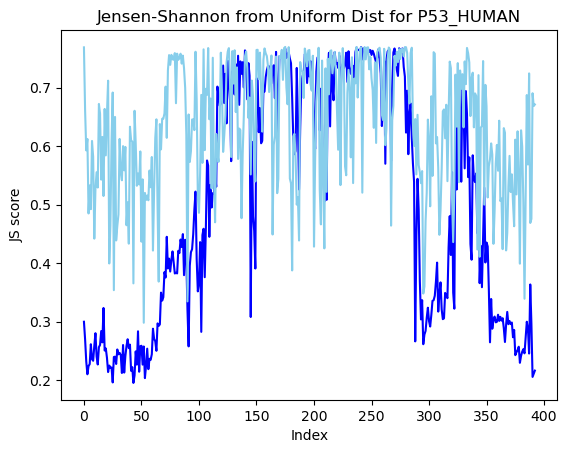

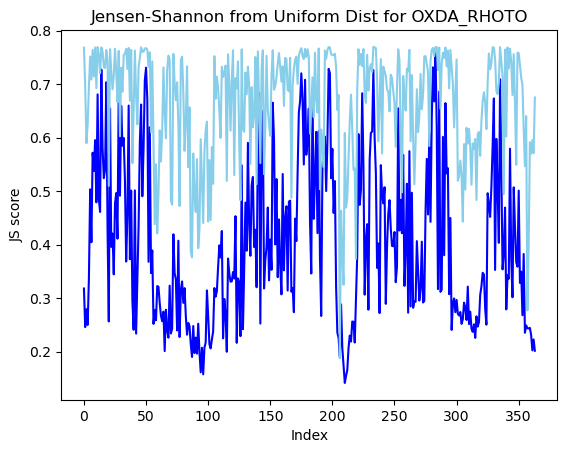

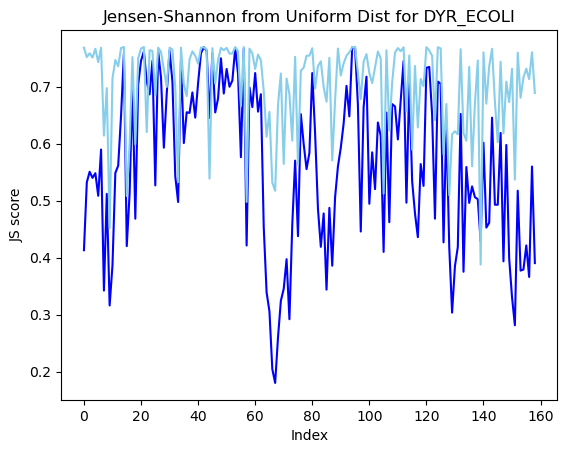

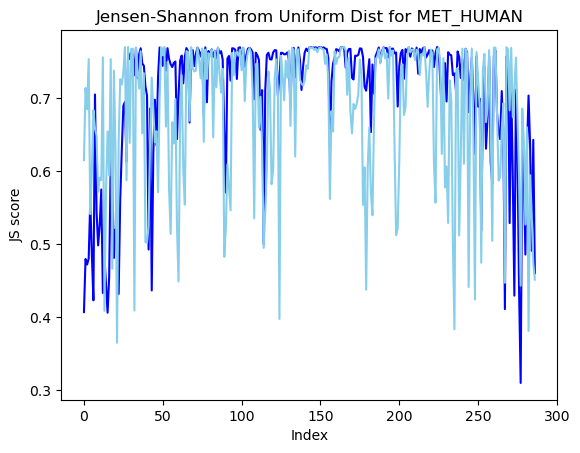

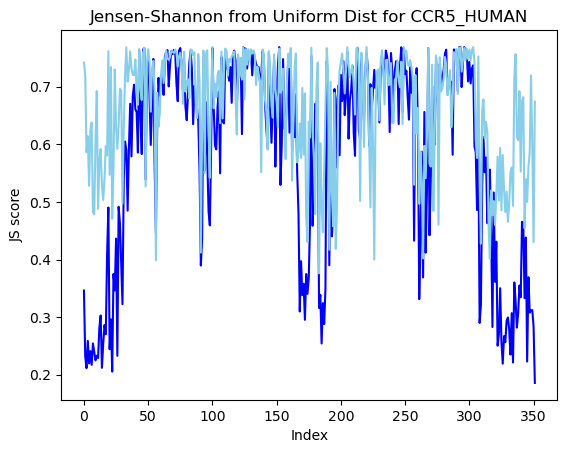

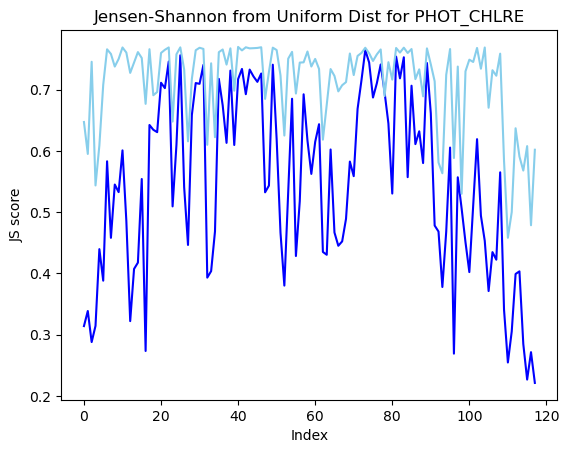

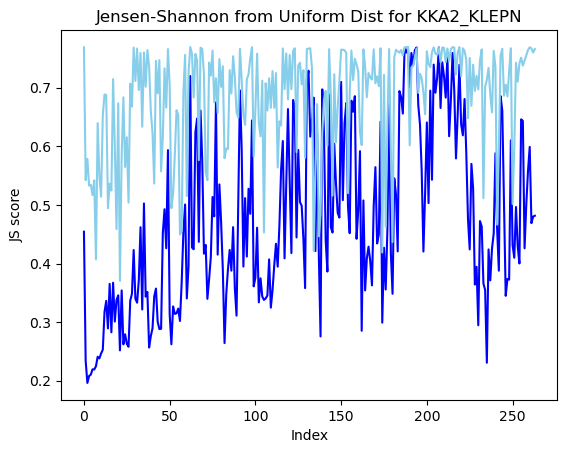

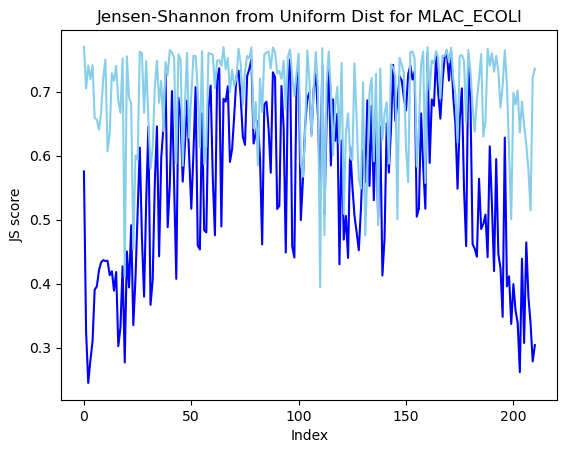

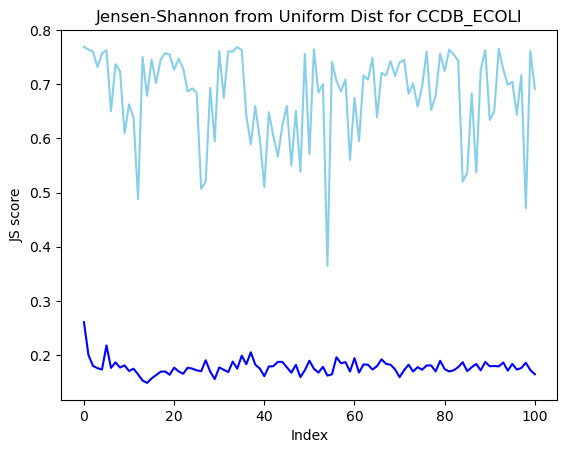

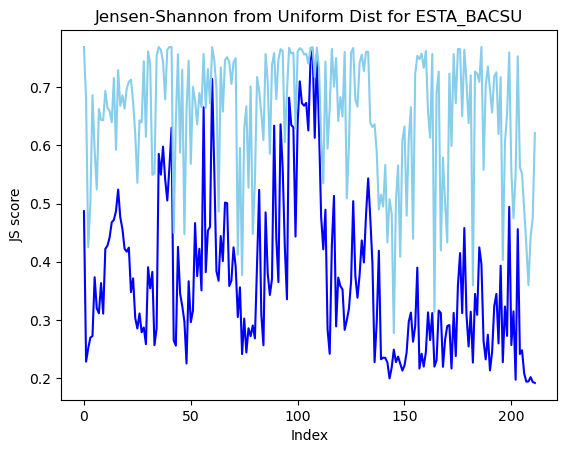

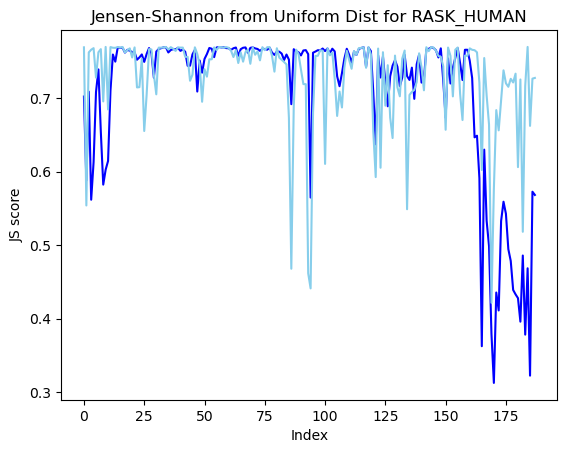

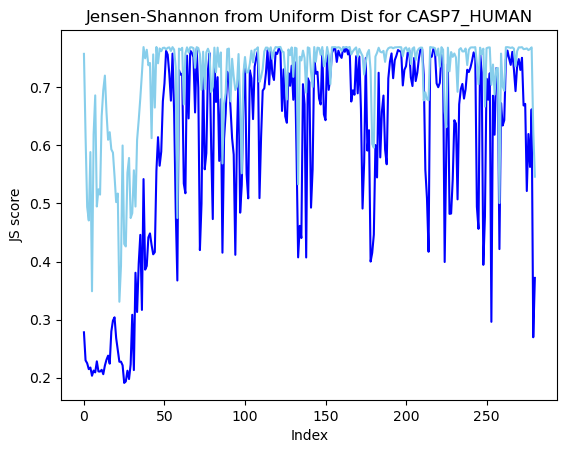

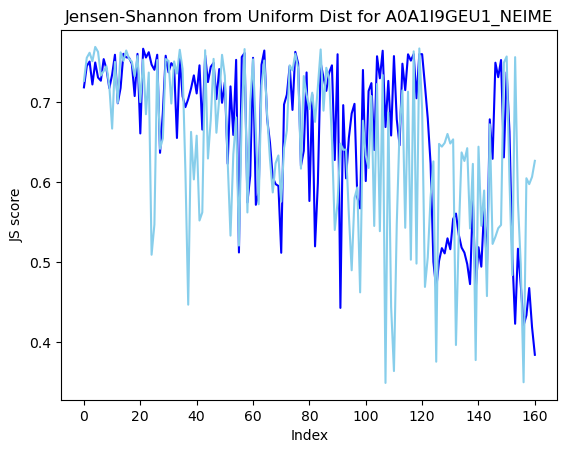

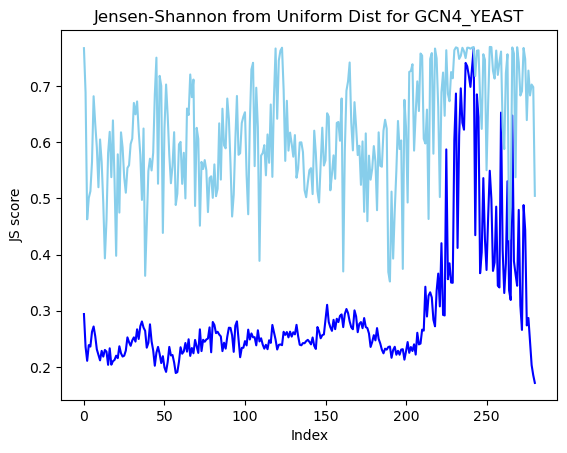

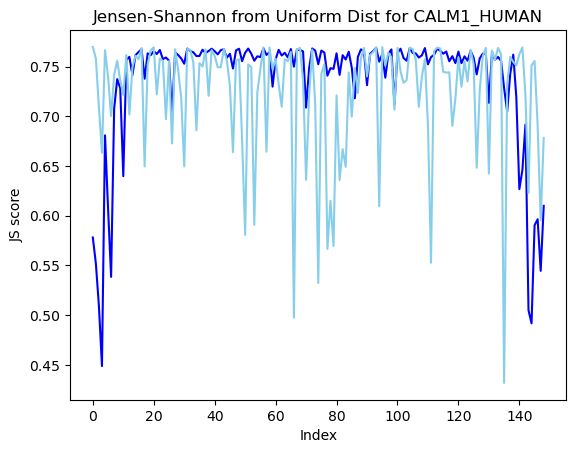

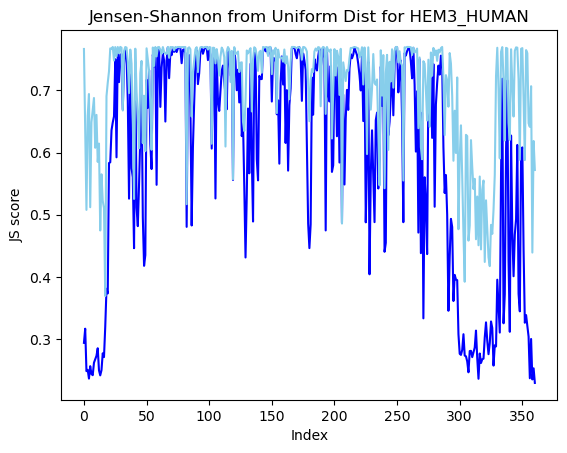

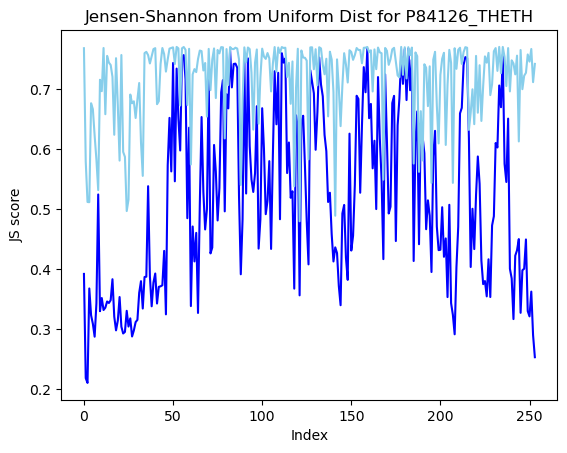

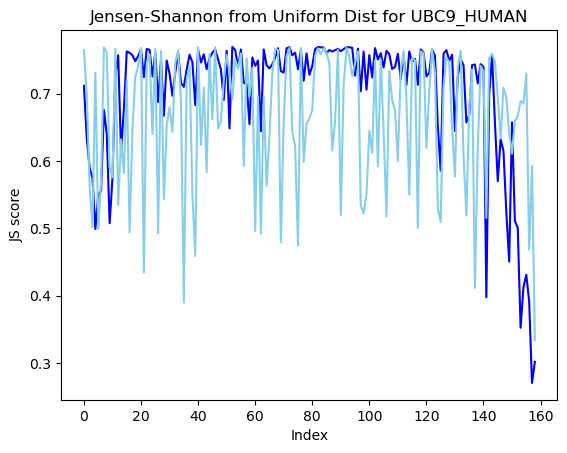

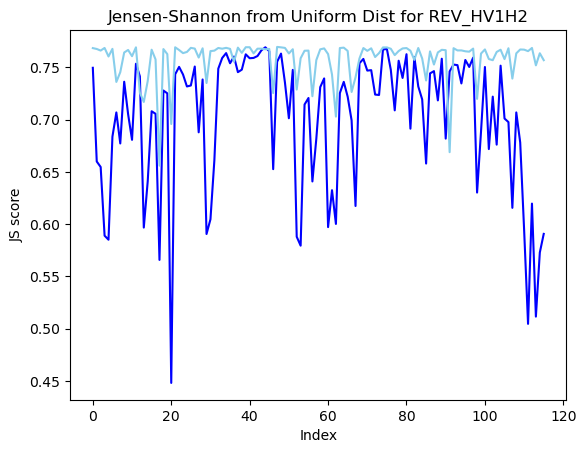

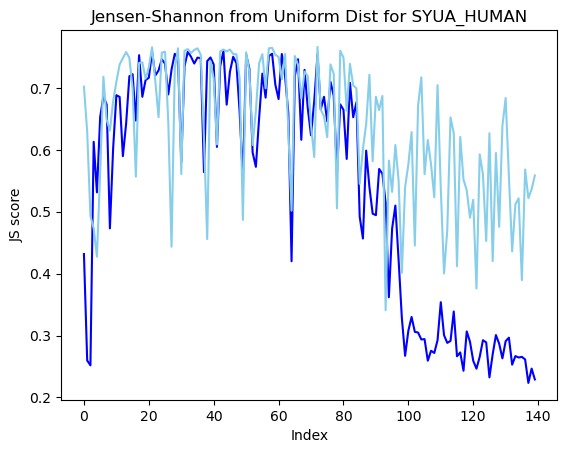

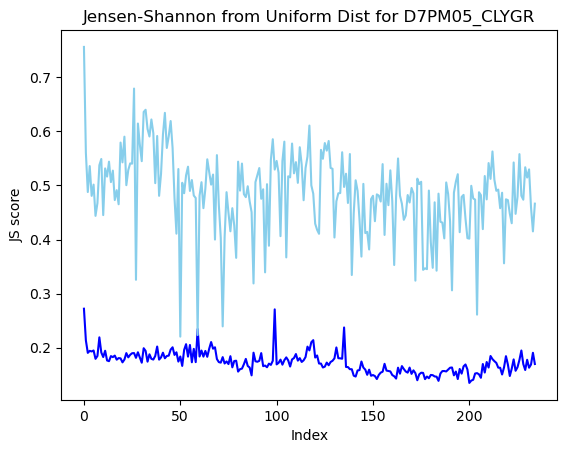

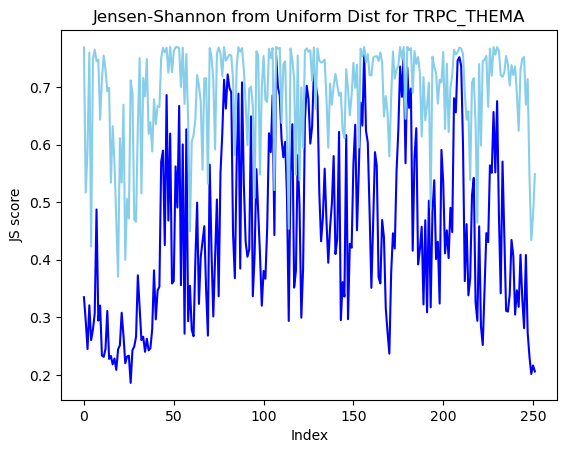

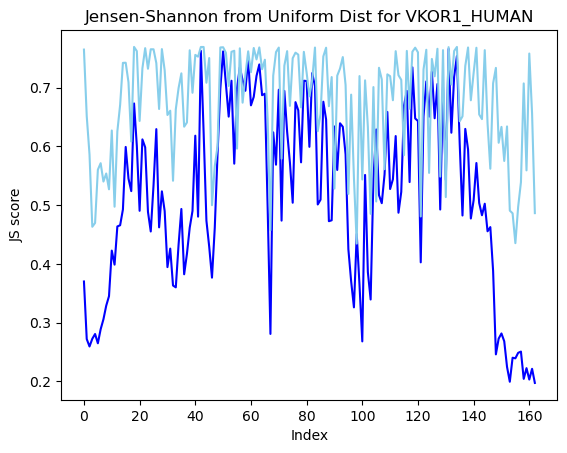

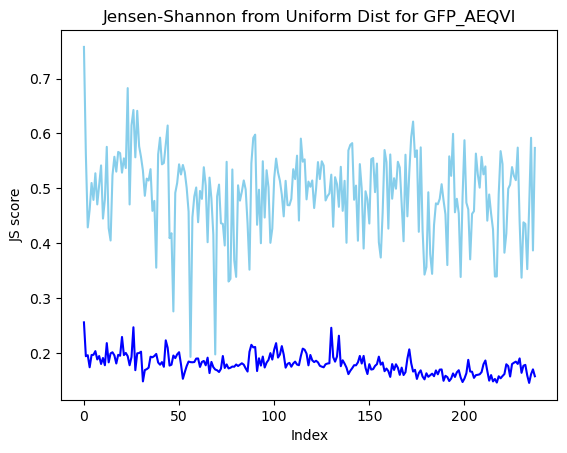

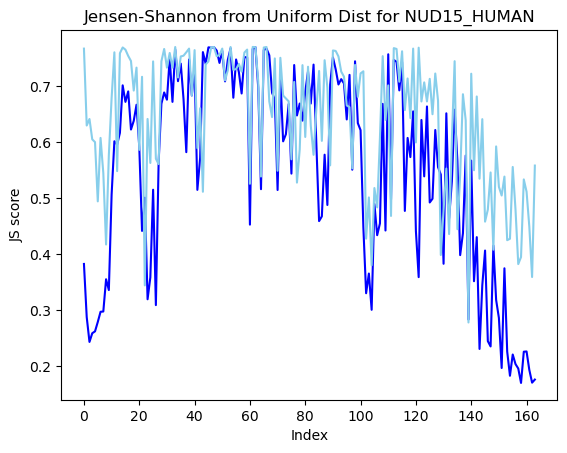

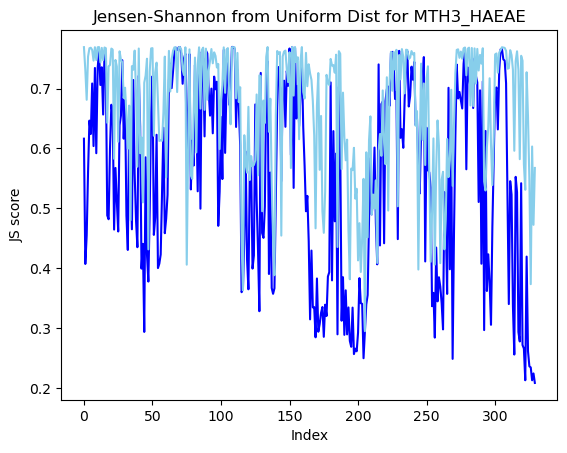

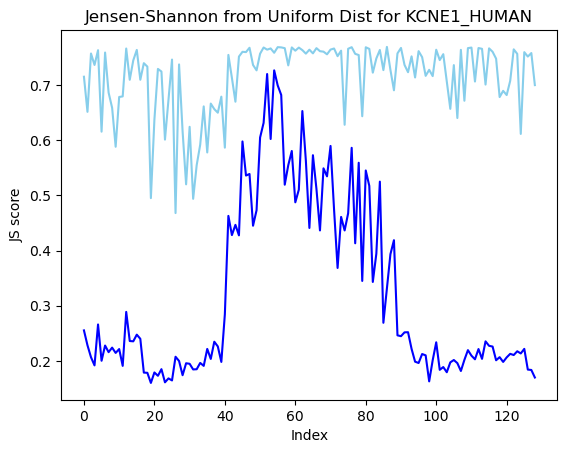

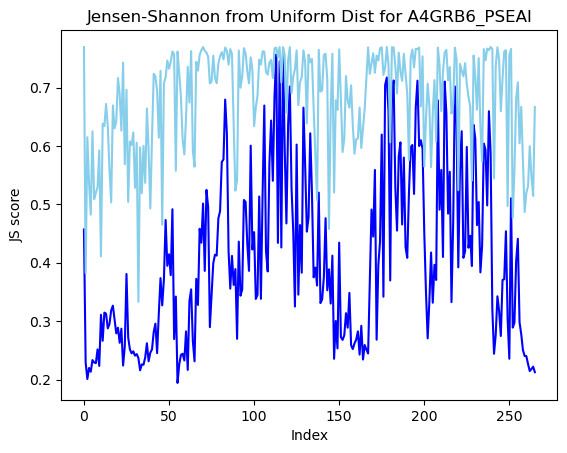

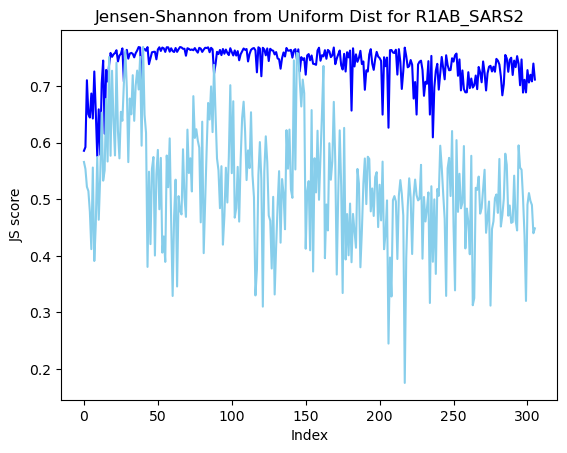

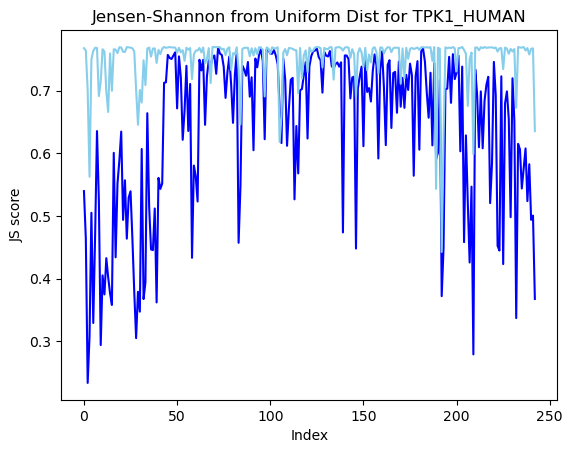

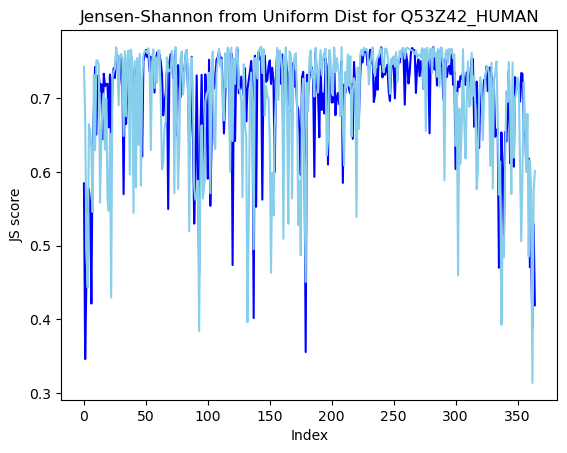

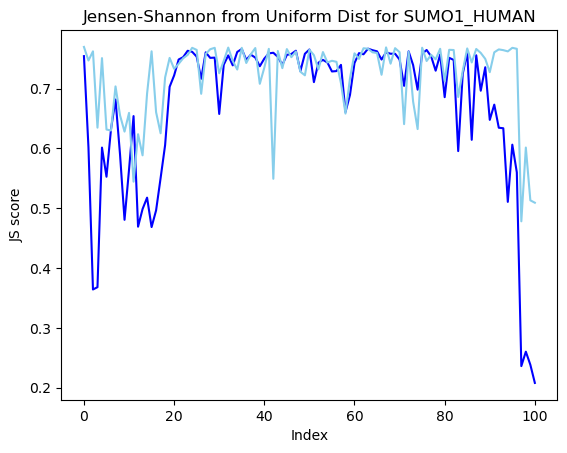

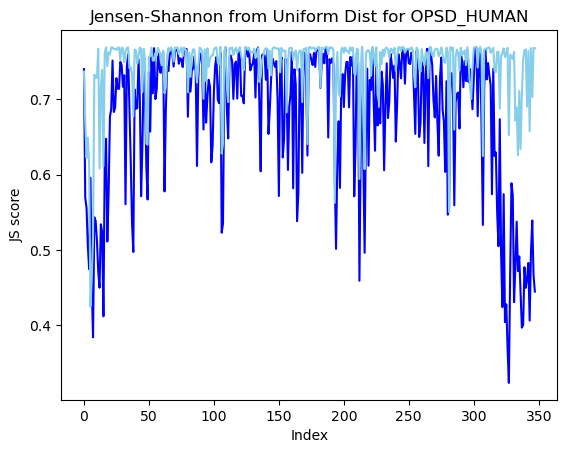

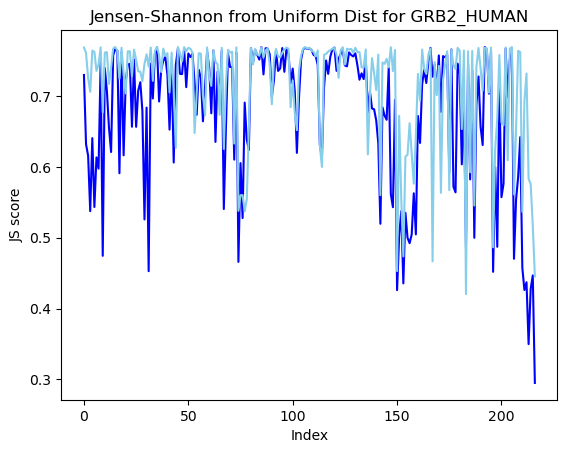

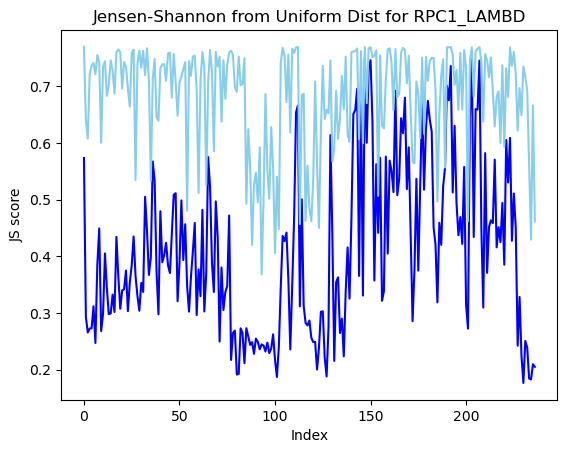

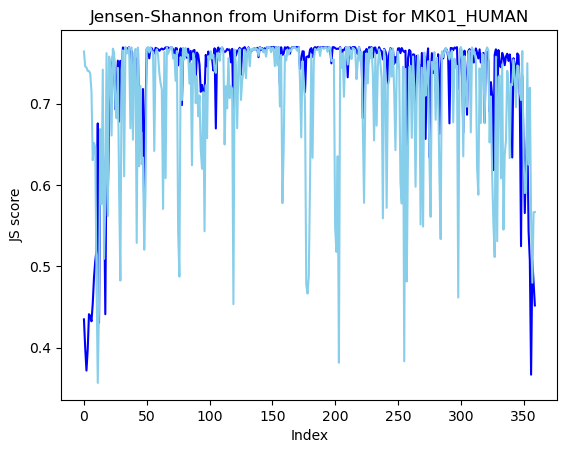

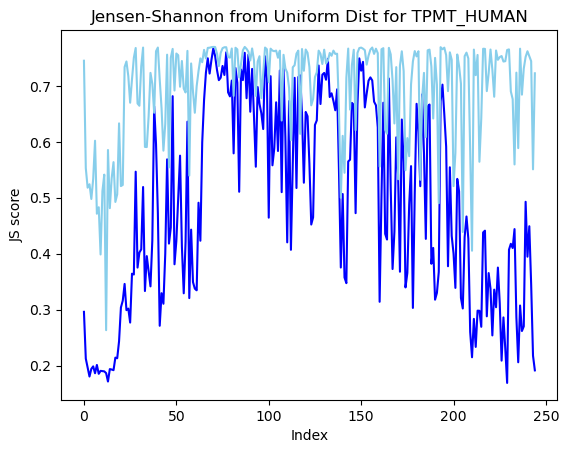

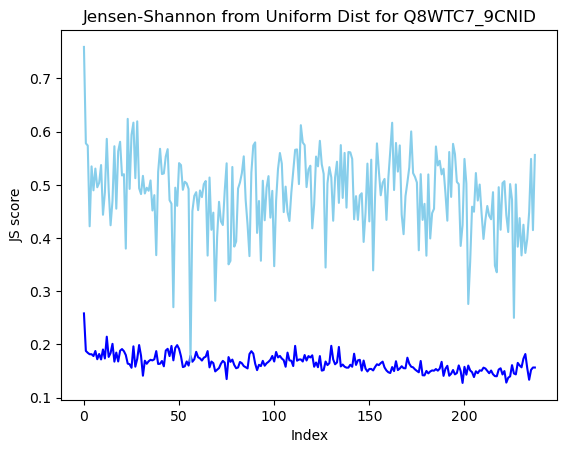

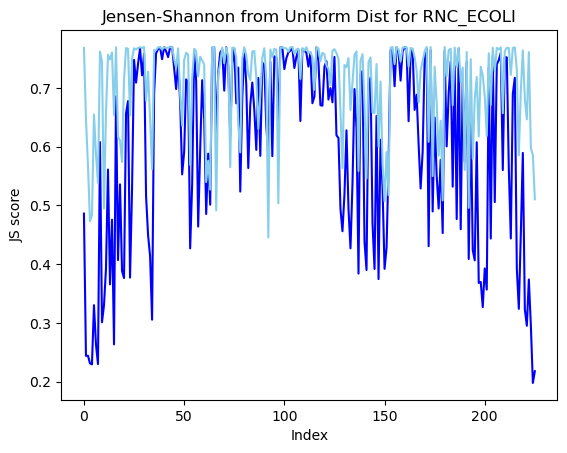

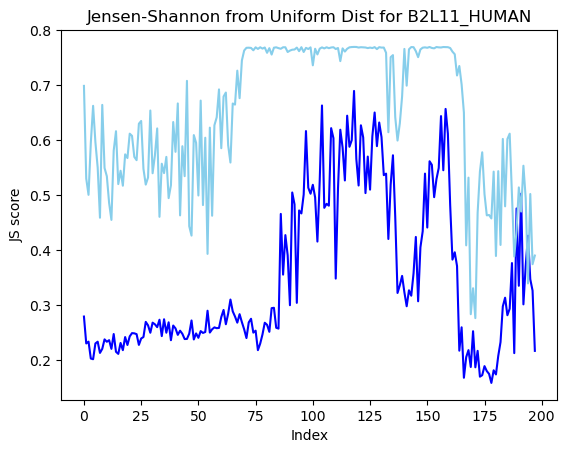

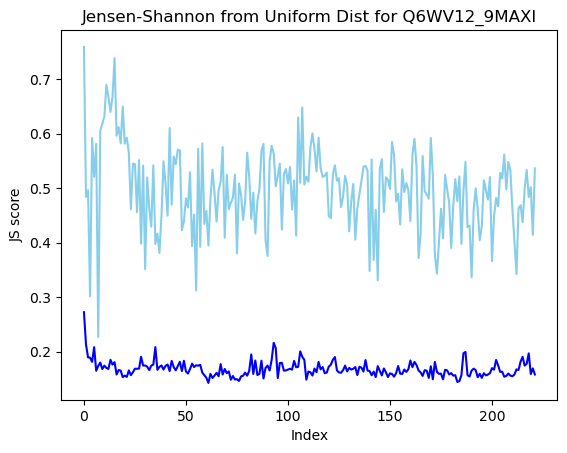

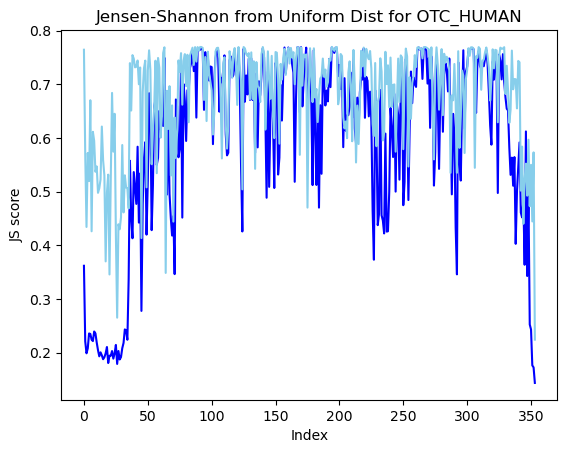

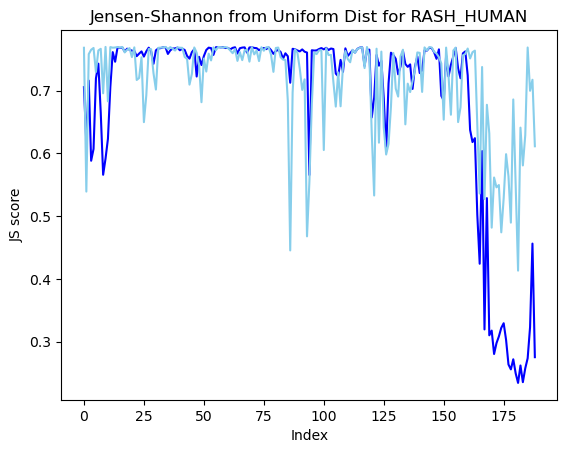

In [21]:
unif_dist = np.ones(20)/20

for i in range(len(med_label_list)):
    key = med_label_list[i][0]
    log_probs_pg = pg_dict[key]['log_probs']
    log_probs_esm = esm_dict[key]['log_probs']

    js_from_unif_pg = []
    js_from_unif_esm = []

    for i in range(len(log_probs_pg)):
        prob_dist_pg = np.exp(log_probs_pg[i])
        js_pg = jensenshannon(prob_dist_pg, unif_dist)
        js_from_unif_pg.append(js_pg)

        prob_dist_esm = np.exp(log_probs_esm[i])
        js_esm = jensenshannon(prob_dist_esm, unif_dist)
        js_from_unif_esm.append(js_esm)
    
    values1 = js_from_unif_pg
    values2 = js_from_unif_esm

    plt.plot(values1, color='blue')
    plt.plot(values2, color='skyblue')

    # Plot quartiles as horizontal lines
    # plt.axhline(q1, color='red', linestyle='--', label='Q1 (25th)')
    # plt.axhline(q2, color='red', linestyle='--', label='Median (50th)')
    # plt.axhline(q3, color='red', linestyle='--', label='Q3 (75th)')

    # plt.plot(values)  
    plt.title(f"Jensen-Shannon from Uniform Dist for {key}")
    plt.xlabel("Index")
    plt.ylabel("JS score")
    plt.grid(False)
    plt.show()

In [ ]:
med_label_list

[('HIS7_YEAST',
  np.float64(-0.019711807976736405),
  np.float64(0.055817431985996424)),
 ('AMIE_PSEAE',
  np.float64(0.6176898893049108),
  np.float64(0.5532622407944272)),
 ('CASP3_HUMAN',
  np.float64(0.544815969481733),
  np.float64(0.6322439801022914)),
 ('RL40A_YEAST',
  np.float64(0.19197416052820312),
  np.float64(0.5243848086958786)),
 ('TRPC_SACS2',
  np.float64(0.5818908474090954),
  np.float64(0.6434747854647281)),
 ('GLPA_HUMAN',
  np.float64(0.2556418803101082),
  np.float64(0.40528687491997406)),
 ('BLAT_ECOLX',
  np.float64(0.6155798918559141),
  np.float64(0.7226676793087004)),
 ('LYAM1_HUMAN', np.float64(0.35159479949055), np.float64(0.3231124752086055)),
 ('SERC_HUMAN',
  np.float64(0.5163905059250465),
  np.float64(0.5484432128528408)),
 ('AICDA_HUMAN',
  np.float64(0.21156477942030058),
  np.float64(0.2835309456422673)),
 ('AACC1_PSEAI',
  np.float64(0.3947373393168098),
  np.float64(0.47697059293175226)),
 ('P53_HUMAN',
  np.float64(0.45811998868974185),
  np.flo

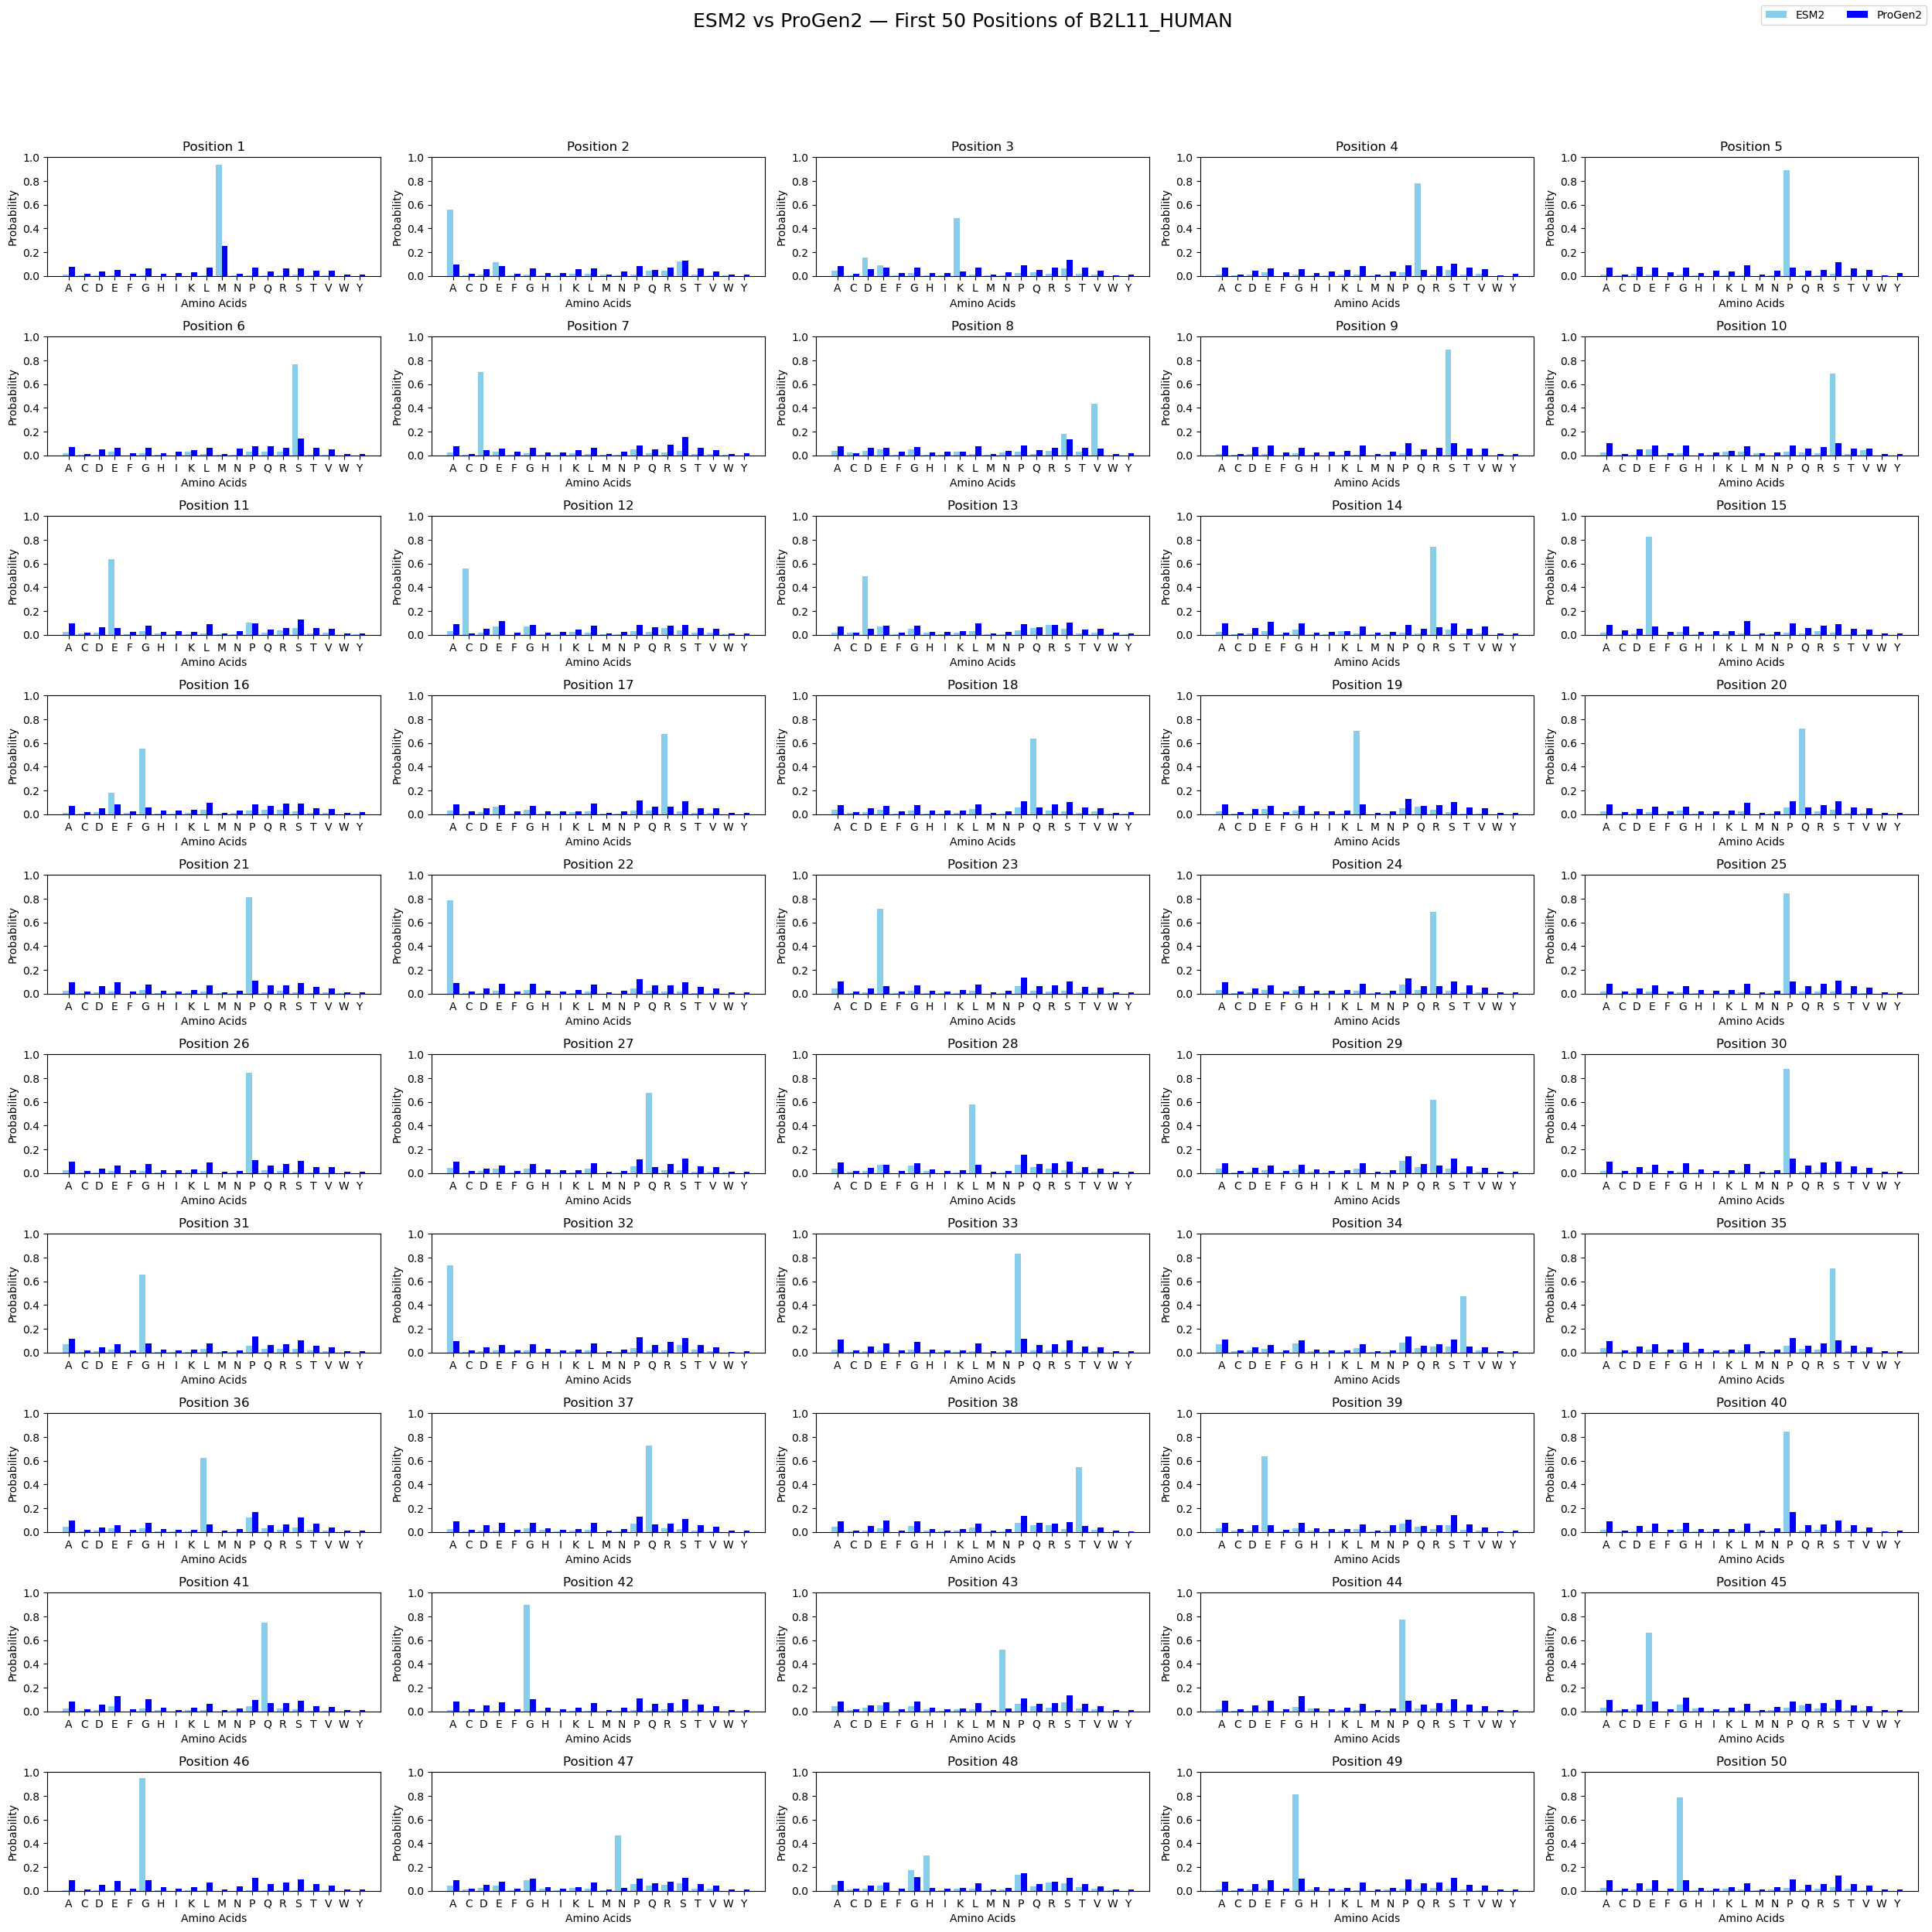

In [17]:
i=50
key = med_label_list[i][0]

A = esm_dict[key]['log_probs']
B = pg_dict[key]['log_probs']

eA = np.exp(A)
eB = np.exp(B)

bound = min([len(B), 50])

pairs_esm = [np.array(eA)[i] for i in range(bound)]
pairs_pg = [np.array(eB)[i] for i in range(bound)]

# Plot settings
fig, axes = plt.subplots(10, 5, figsize=(25, 25))
axes = axes.flatten()
bar_width = 0.4
x = torch.arange(1, 21)

for i, ax in enumerate(axes):
    dist1 = pairs_esm[i]
    dist2 = pairs_pg[i]
    ax.bar(x - bar_width/2, dist1, width=bar_width, label="ESM2", color="skyblue")
    ax.bar(x + bar_width/2, dist2, width=bar_width, label="ProGen2", color="blue")
    ax.set_title(f"Position {i+1}")
    ax.set_xlabel("Amino Acids")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(aa_list)  
    ax.tick_params(axis='x', rotation=0)

# Add a single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=2)

fig.suptitle(f"ESM2 vs ProGen2 — First {bound} Positions of {key}", fontsize=18, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

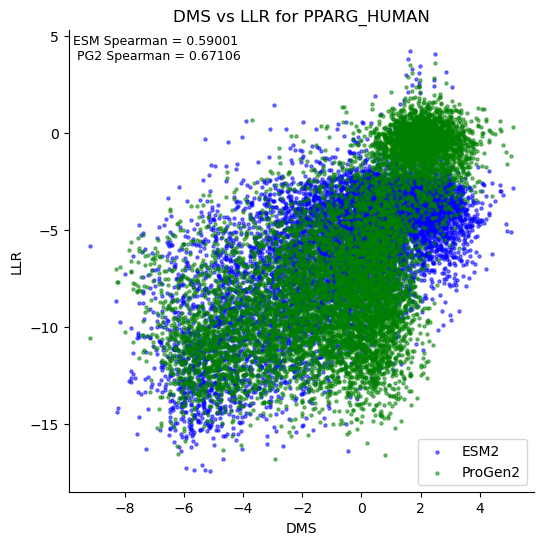

In [19]:
i = 25

x = esm_dict[keys[i]]['DMS']
y1 = esm_dict[keys[i]]['llr_matrix']
y2 = pg_dict[keys[i]]['llr_matrix']

sp_val_esm, p_val_esm = esm_dict[keys[i]]['spearman_DMS']
sp_val_pg, p_val_pg = pg_dict[keys[i]]['spearman_DMS']

mask1 = ~np.isnan(x) & ~np.isnan(y1)
x_clean = x[mask1]
y1_clean = y1[mask1]

mask2 = ~np.isnan(x) & ~np.isnan(y2)
x_clean = x[mask2]
y2_clean = y2[mask2]



# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y1_clean, color='blue', label = 'ESM2', alpha=0.5, s=5)
plt.scatter(x_clean, y2_clean, color='green', label = 'ProGen2', alpha=0.5, s=5)
plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)
ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"ESM Spearman = {round(sp_val_esm,5)} \n PG2 Spearman = {round(sp_val_pg,5)}",
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend()
plt.show()

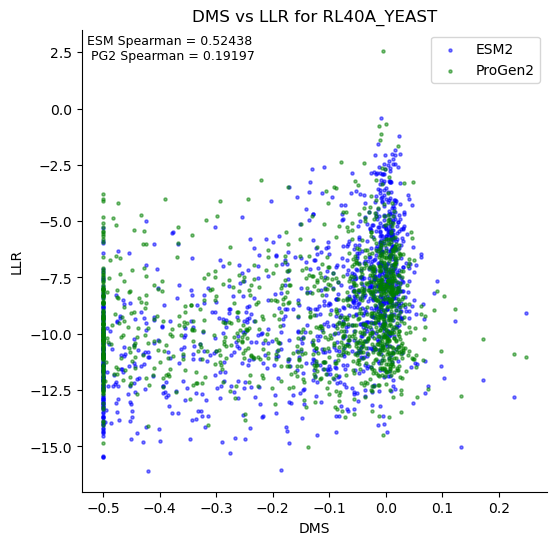

In [21]:
i = 8

x = esm_dict[keys[i]]['DMS']
y1 = esm_dict[keys[i]]['llr_matrix']
y2 = pg_dict[keys[i]]['llr_matrix']

sp_val_esm, p_val_esm = esm_dict[keys[i]]['spearman_DMS']
sp_val_pg, p_val_pg = pg_dict[keys[i]]['spearman_DMS']

mask1 = ~np.isnan(x) & ~np.isnan(y1)
x_clean = x[mask1]
y1_clean = y1[mask1]

mask2 = ~np.isnan(x) & ~np.isnan(y2)
x_clean = x[mask2]
y2_clean = y2[mask2]



# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y1_clean, color='blue', label = 'ESM2', alpha=0.5, s=5)
plt.scatter(x_clean, y2_clean, color='green', label = 'ProGen2', alpha=0.5, s=5)
plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)
ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"ESM Spearman = {round(sp_val_esm,5)} \n PG2 Spearman = {round(sp_val_pg,5)}",
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend()
plt.show()

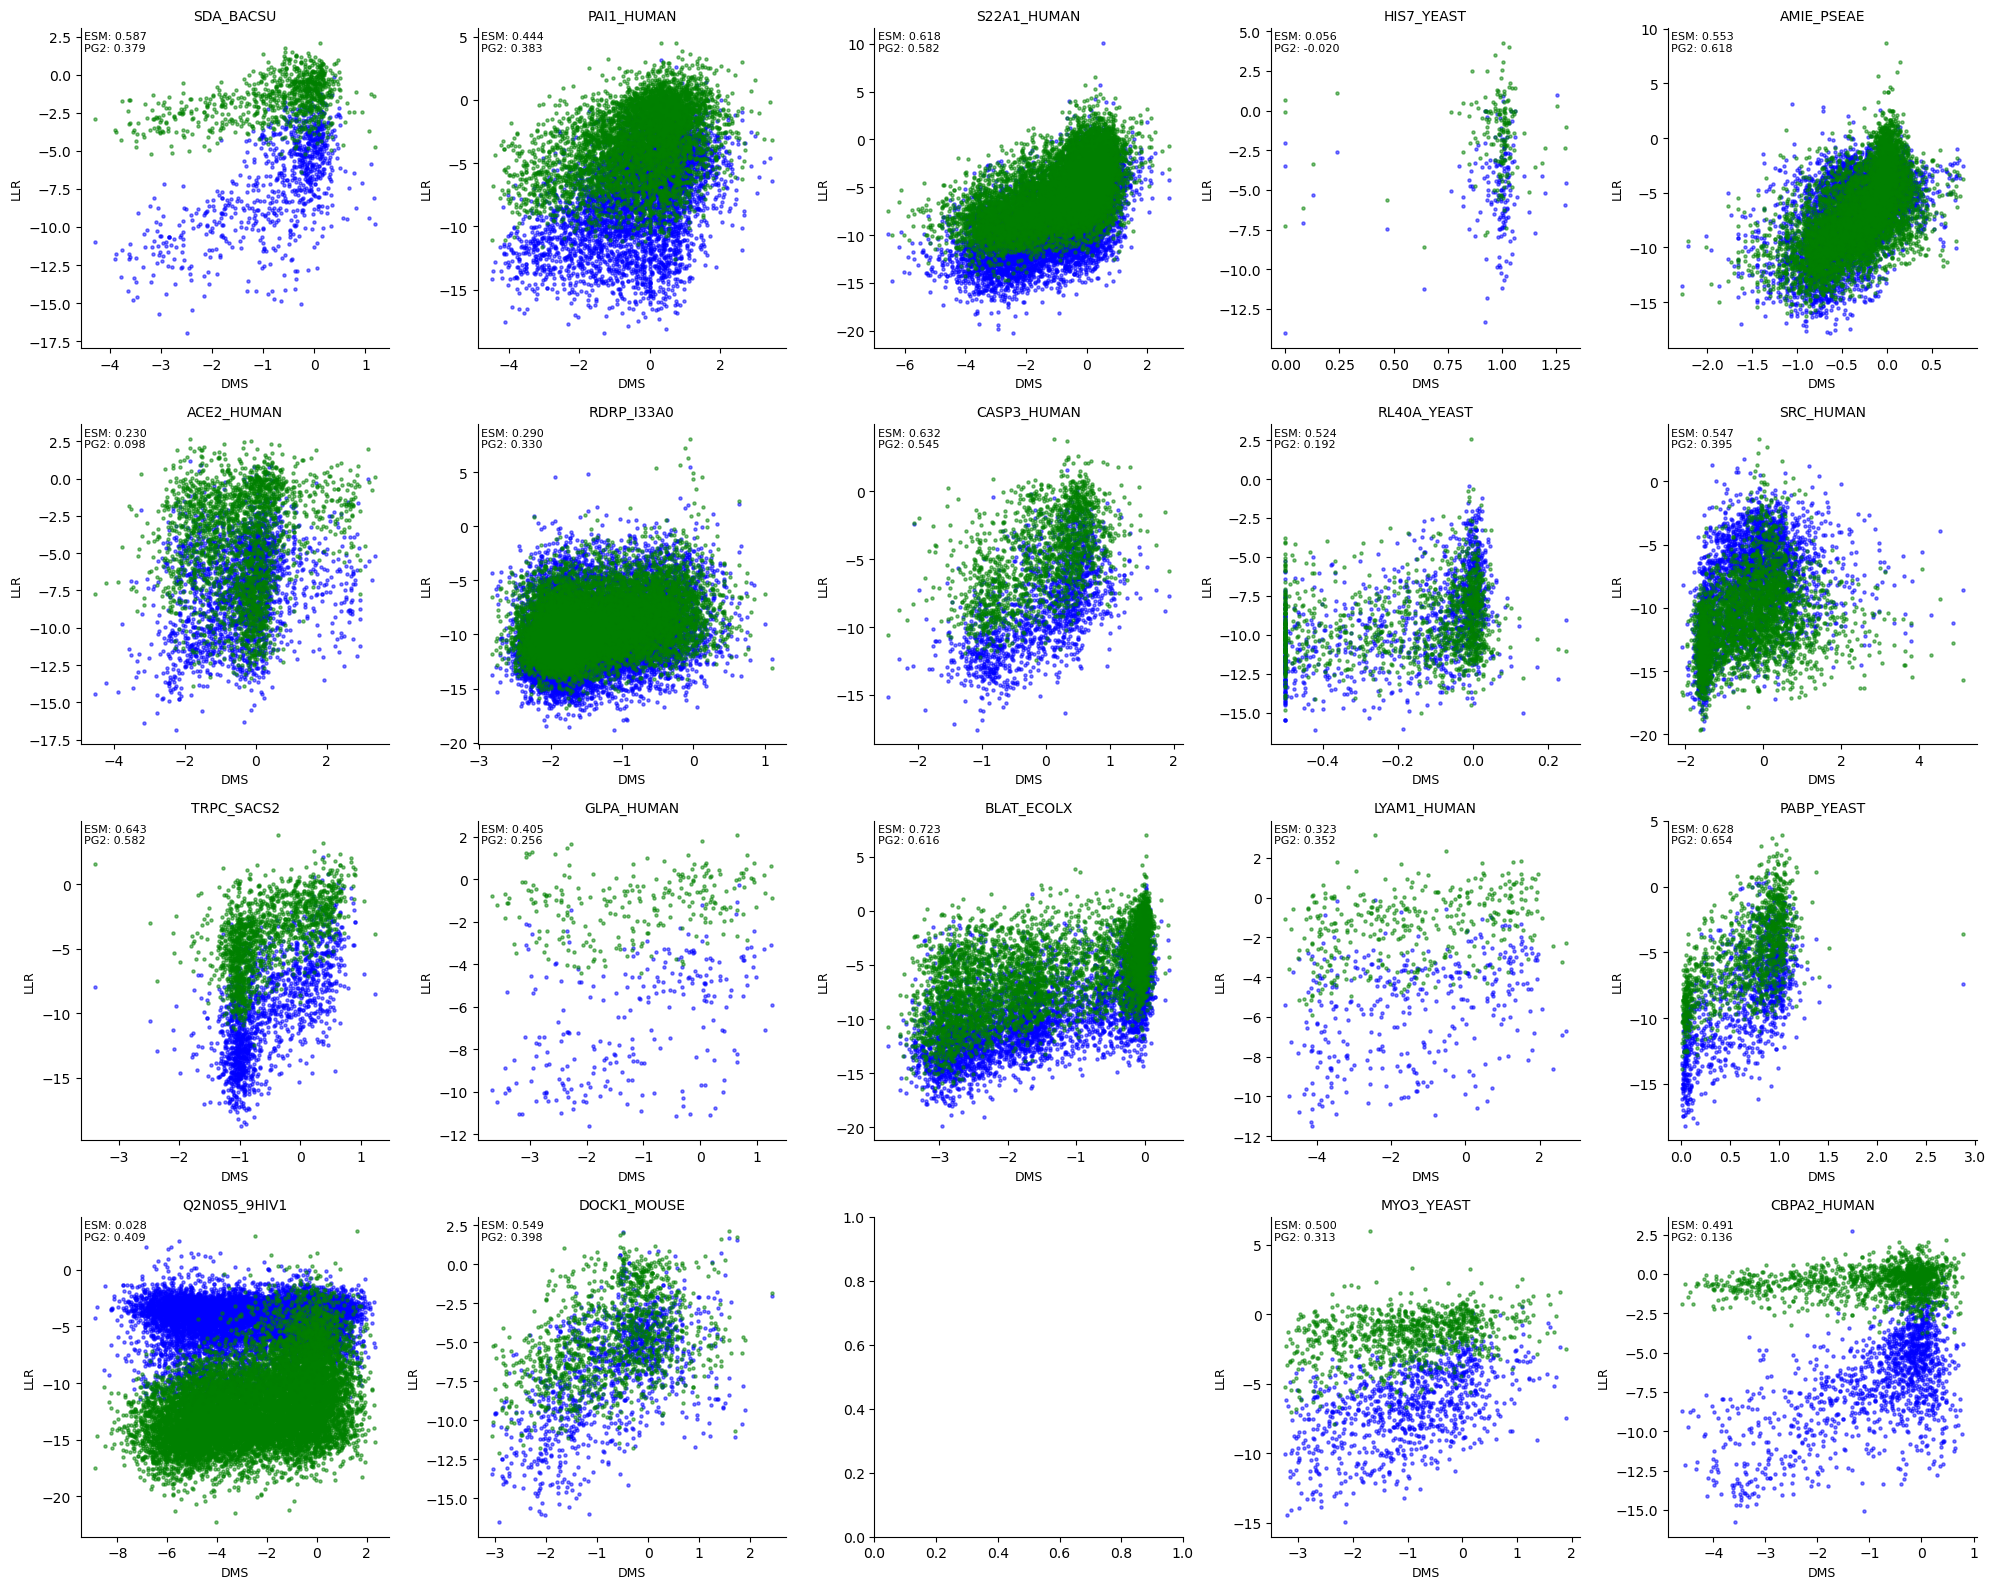

In [20]:

indices = list(range(20))  # or any 20 values of i
nrows, ncols = 4, 5

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 16))
axes = axes.flatten()  # flatten to 1D array for easy iteration

for idx, i in enumerate(indices):
    ax = axes[idx]
    
    if 'llr_matrix' in pg_dict[keys[i]].keys():

        x = esm_dict[keys[i]]['DMS']
        y1 = esm_dict[keys[i]]['llr_matrix']
        y2 = pg_dict[keys[i]]['llr_matrix']
        
        sp_val_esm, _ = esm_dict[keys[i]]['spearman_DMS']
        sp_val_pg, _ = pg_dict[keys[i]]['spearman_DMS']
        
        # Clean NaNs
        mask1 = ~np.isnan(x) & ~np.isnan(y1)
        mask2 = ~np.isnan(x) & ~np.isnan(y2)
        
        x1_clean, y1_clean = x[mask1], y1[mask1]
        x2_clean, y2_clean = x[mask2], y2[mask2]
        
        # Scatter plots
        ax.scatter(x1_clean, y1_clean, color='blue', alpha=0.5, s=5, label='ESM')
        ax.scatter(x2_clean, y2_clean, color='green', alpha=0.5, s=5, label='PG2')
        
        # Axes labels
        ax.set_xlabel("DMS", fontsize=9)
        ax.set_ylabel("LLR", fontsize=9)
        
        # Title
        ax.set_title(keys[i], fontsize=10)
        
        # Spearman annotations
        ax.text(
            0.01, 0.99,
            f"ESM: {sp_val_esm:.3f}\nPG2: {sp_val_pg:.3f}",
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            horizontalalignment='left'
        )
    
    # Remove top/right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Optional: grid off
    ax.grid(False)

# Adjust spacing
plt.tight_layout()
plt.show()


In [79]:
esm_sp_list = []
pg_sp_list = []

for key in pg_dict.keys():
    if 'spearman_DMS' in pg_dict[key].keys():
        esm_sp, _ = esm_dict[key]['spearman_DMS']
        pg_sp, _ = pg_dict[key]['spearman_DMS']

        esm_sp_list.append(esm_sp)
        pg_sp_list.append(pg_sp)

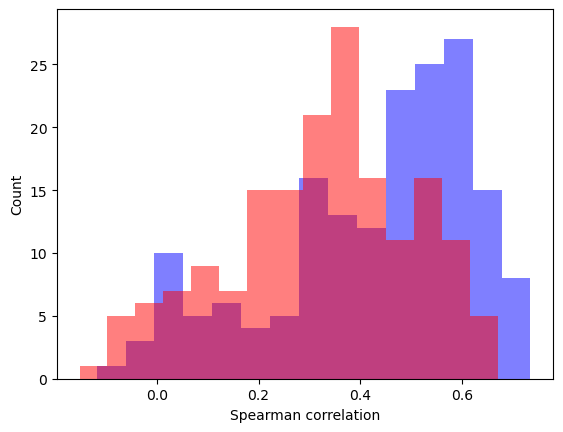

In [83]:
plt.figure()
plt.hist(esm_sp_list, bins=15, color = 'blue', alpha = 0.5)
plt.hist(pg_sp_list, bins=15, color = 'red', alpha = 0.5)
plt.xlabel("Spearman correlation")
plt.ylabel("Count")

plt.show()

In [41]:
esm_pg_sp_list=[]

for key in keys:
    if 'llr_matrix' in pg_dict[key].keys():
        esm_llr = esm_dict[key]['llr_matrix']
        pg_llr = pg_dict[key]['llr_matrix']
        sp = spearman_ignore_nan(esm_llr, pg_llr)
        esm_pg_sp_list.append((key, sp[0]))

In [40]:
esm_pg_sp_list_unzip = list(zip(*esm_pg_sp_list))

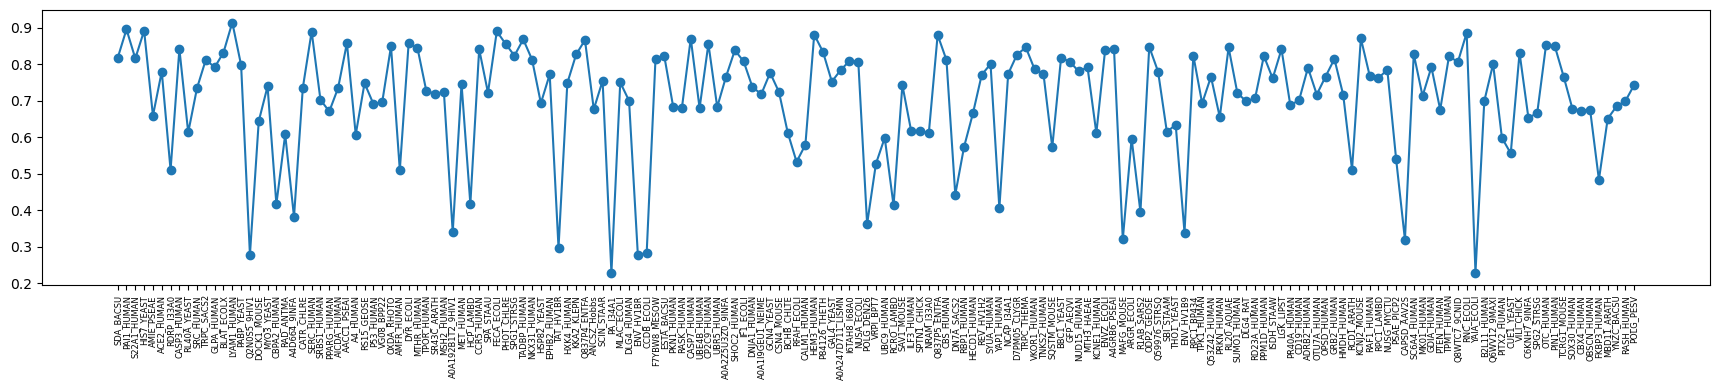

In [51]:
names = esm_pg_sp_list_unzip[0]
sp_vals = esm_pg_sp_list_unzip[1]

fig, ax = plt.subplots(
    figsize=( 0.1*len(names), 4)  # ← scale width with number of labels
)

ax.plot(sp_vals, marker='o')

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=6)

fig.tight_layout()
# plt.show()

# plt.figure()
# plt.scatter(names, sp_vals)
# plt.xticks(
#     ticks=range(len(names)),
#     labels=names,
#     rotation=90,
#     fontsize=2
# )
# plt.xlabel("Spearman correlation")
# plt.ylabel("Count")

plt.show()

In [ ]:
plt.figure()
plt.scatter(sp_len, sp_diff)
plt.plot(sp_len,np.zeros(len(sp_len)), color='red')
plt.xlabel("Sequence length")
plt.ylabel("ESM - ProGen2 Spearman")

plt.show()

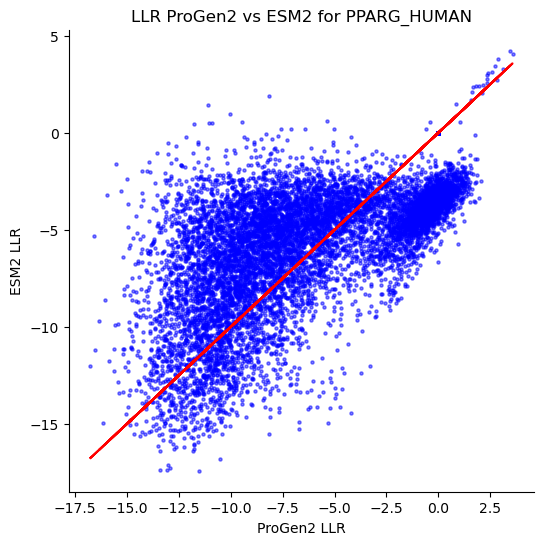

In [23]:
i = 25

x = pg_dict[keys[i]]['llr_matrix']
y = esm_dict[keys[i]]['llr_matrix']

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.5, s=5)
plt.plot(x,x,color='red')
plt.xlabel("ProGen2 LLR")
plt.ylabel("ESM2 LLR")
plt.title(f"LLR ProGen2 vs ESM2 for {keys[i]}")
plt.grid(False)
ax = plt.gca()
# ax.text(
#     0.01, 0.99,                
#     f"ESM Spearman = {round(sp_val_esm,5)} \n PG2 Spearman = {round(sp_val_pg,5)}",
#     transform=plt.gca().transAxes,
#     fontsize=9,
#     verticalalignment='top',
#     horizontalalignment='left',
# )
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

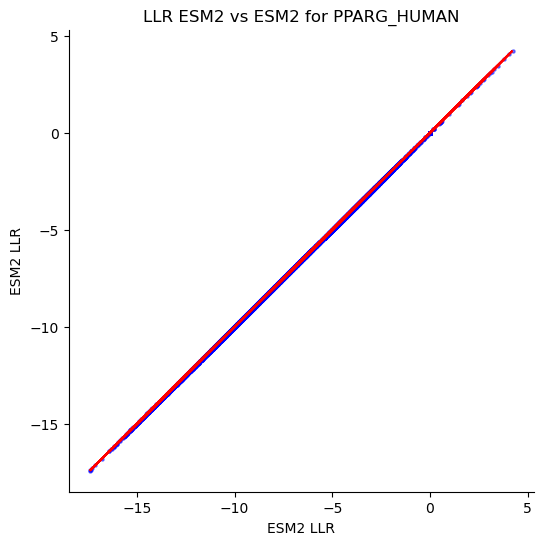

In [22]:
i = 25

x = esm_dict[keys[i]]['llr_matrix']
y = esm_dict[keys[i]]['llr_matrix']

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.5, s=5)
plt.plot(x,x,color='red')
plt.xlabel("ESM2 LLR")
plt.ylabel("ESM2 LLR")
plt.title(f"LLR ESM2 vs ESM2 for {keys[i]}")
plt.grid(False)
ax = plt.gca()
# ax.text(
#     0.01, 0.99,                
#     f"ESM Spearman = {round(sp_val_esm,5)} \n PG2 Spearman = {round(sp_val_pg,5)}",
#     transform=plt.gca().transAxes,
#     fontsize=9,
#     verticalalignment='top',
#     horizontalalignment='left',
# )
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()